# DAI Mission — Proposal
**Data & AI in Economics | TU Dortmund**


## 1. Team

| Role | Name               | Student ID |
|------|--------------------|------------|
| Lead | Emma Kliushnichenko | 242989     |
| Member | Mohamed Gomaa | 283950     |
| Member  | Ahmed Abdelrazek | 284304     |


## 2. Mission Title & Research Question

**Title:** *[Gender Differences in Executive Roles based on BoardEx Europe data]*

**Research question:**  

Which individual characteristics, including education, age, nationality, professional experience, board experience, committee involvement, and network position, influence the probability of holding a top position in a company, and does gender remain associated with this probability after investigating on these factors?


**Why it matters:**     

As a data scientist student, I became interested in salary levels in IT. Based on the data from Kununu, a salary gap between men and women still exists in Germany. According to their public information, female data scientists earn around 2,000 euros less per year than male data scientists.

Gender inequality has already been studied by many researchers. For example, the recent work of Nobel Prize winner Claudia Goldin on gender gaps in career outcomes highlights the systematic nature of wage inequality, not only in the USA but also in other countries. Gender inequality in labor markets is not only reflected in employment rates or salaries, but also in access to high responsibility positions.

This project studies whether such differences are visible among directors and executives in European organizations. The main focus is on whether women and men differ in their access to top roles.


## 3. Data

**Source(s):**  
The project uses BoardEx Europe data accessed through Wharton Research Data Services (WRDS). BoardEx-Europe provides information on 1.7 million corporate executives and board members from over 2.2 million organizations based in Europe. The data are used for academic purposes under the access terms of WRDS and BoardEx. Access is provided through the TU Dortmund institutional licence.

**URL:** https://wrds-www.wharton.upenn.edu/pages/get-data/boardex/boardex-europe/  

The files are used:

- `individual_profile_education.csv`: recorded education
- `individual_profile_employment.csv`: employment and roles in the company
- `individual_profile_details.csv`: demographic information
- `board_and_director_committees.csv`: board and committee roles
- `individual_networks.csv`: professional networks
- `company_profile.csv`: information about companies
- `annual_remuneration.csv`: compensation information

**Unit of observation:**  

The main unit of observation is the role in a company from `individual_profile_employment.csv`. All tables are merged by `directorid`, and tables that are related to companies data are merged by `companyid` or by both `directorid` and `companyid`. One director can have several role records, and one company can be connected to many directors.


**Key variables:**  

| Variable / group | Type           | Role | Description |
|---|----------------|---|---|
| `directorid` | Numeric        | ID | Individual identifier. |
| `directorname` | Text           | ID | Individual name. |
| `companyid` | Numeric        | ID | Company identifier. |
| `companyname` | Text           | ID | Company name. |
| `gender`, `female` | Categorical    | Feature | Gender and female indicator. |
| `rolename`, `rolename_clean` | Text           | Feature | Role title. |
| `is_ceo`, `is_cfo`, `is_coo`, `is_cto_cio`, `is_other_csuite`, `is_president`, `is_md`, `is_executive`, `is_senior_management`, `has_any_executive_role` | Binary         | Target | Executive and senior leadership indicators. |
| `brdposition`, `brdposition_binary`, `ned`, `ned_binary`, `is_board_member_ed`, `is_board_member_sd`, `is_ned`, `is_independent_director`, `is_nonexecutive_independent`, `is_chairman` | Binary         | Control | Board, non-executive, independent, and chairman indicators. |
| `is_committee_member`, `is_advisor`, `is_consultant`, `is_partner`, `is_founder`, `is_owner_investor`, `is_employee_representative`, `is_manager_operational` | Binary         | Feature | Additional role indicators. |
| `is_unclassified_role`, `role_indicator_sum` | Numeric        | Quality | Checks missed or overlapping role classifications. |
| `leadershipteam`, `leadershipteam_binary` | Binary         | Target | Leadership status. |
| `hocountryname` | Categorical    | Control | Company head-office country. |
| `orgtype`, `orgtype_company` | Categorical    | Control | Organization type. |
| `sector_company` | Categorical    | Control | Company sector. |
| `age` | Numeric        | Control | Individual age. |
| `nationality` | Categorical    | Control | Individual nationality. |
| `num_qualifications`, `qualifications_raw`, `has_mba`, `has_phd`, `has_master`, `has_bachelor` | Numeric/Binary | Feature | Education information. |
| `datestartrole`, `dateendrole`, `start_year`, `end_year`, `role_active_currently` | Date           | Filter | Role timing and current-role indicator. |

**Note**:  The role indicators were created by one-hot encoding selected values from `rolename` and `rolename_clean`. This means that role titles were transformed into binary variables, such as `is_ceo`, `is_cfo`, `is_coo`, `is_board_member_ed`, and `has_any_executive_role`, where 1 indicates that the observation belongs to that role category and 0 otherwise. The same approach was also used for education variables, where recorded qualifications were transformed into binary indicators such as `has_mba`, `has_phd`, `has_master`, and `has_bachelor`.


### Potential data quality issues

The final dataset contains **1,507,568 observations**, **56 variables**, **322,747 unique director IDs**, and **489,540 unique company IDs**.

##### Missing values

`fulltextdescription` is 65.71% missing, `nationality` is 61.80% missing, `sector_company` is 42.72% missing, and `age` is 37.25% missing. Education variables are available for only about **19.93–19.94%** of observations. They are kept because they are relevant.

There are 7 missing values in the gender data. Since this is a very small part of the whole dataset and the reason for these missing values could not be identified, these observations will be removed.

##### Placeholders

In `datestartrole`, `1900-01-01` likely indicates an unknown start date. In `dateendrole`, `9000-01-01` and `9999-12-31` likely indicate ongoing roles and contain most of the data, so we will not use exact end dates as reliable values. However, we will still look at ongoing roles.

##### Selection bias

Some datasets, such as Individual Profile Employment and Annual Remuneration, were downloaded for **2016–2026**, while other files do not clearly specify the same time period. Annual Remuneration was almost entirely missing after merging, so compensation variables were removed from the main project.

##### Measurement error

The **gender distribution is unequal**. The dataset includes **1,210,252 male observations** and **297,309 female observations**. The analysis will use scaled measures to account for this gap.


##### Flagged features

Some role indicators, such as CEO etc. were created manually from `rolename`. Since job titles are not always standardized, some roles may be missed and assigned to more than one category. Therefore, `is_unclassified_role` and `role_indicator_sum` are used only as checks for the role classification.


In [1]:
import os
import pandas as pd
import numpy as np

os.chdir("/Users/emma_kliushnichenko/Desktop/data and ai in economics")

df = pd.read_csv("data.csv", low_memory=False)

print("Rows:", len(df))
print("Columns:", df.shape[1])
print("Unique id directors:", df["directorid"].nunique())
print("Unique id companies:", df["companyid"].nunique())

df.head()

Rows: 1507568
Columns: 56
Unique id directors: 322747
Unique id companies: 489540


,directorid,directorname,companyid,companyname,gender,female,datestartrole,dateendrole,rolename,rolename_clean,...,sector_company,orgtype_company,cccountryname,fulltextdescription,num_qualifications,qualifications_raw,has_mba,has_phd,has_master,has_bachelor
0,328039,William Burgess,10,FIRST ACTIVE PLC (De-listed 01/2004),M,0.0,1900-01-01,9999-12-31,NED,ned,...,NaN,Quoted,Unknown,NaN,2.0,Degree; Fellow,0.0,0.0,0.0,0.0
1,885377,Doctor António Palma Ramalho,10,FIRST ACTIVE PLC (De-listed 01/2004),M,0.0,1900-01-01,9999-12-31,Director - SD,director - sd,...,NaN,Quoted,Unknown,NaN,3.0,Graduated; MSc; Postgraduate Degree,0.0,0.0,1.0,0.0
2,2765991,Clodagh NicCanna,10,FIRST ACTIVE PLC (De-listed 01/2004),F,1.0,1900-01-01,9999-12-31,Executive,executive,...,NaN,Quoted,Unknown,NaN,2.0,BSc; MSc,0.0,0.0,1.0,1.0
3,1321349,David Young,11,First Agate Capital Corp,M,0.0,2018-06-01,9000-01-01,Managing Partner,managing partner,...,NaN,NaN,NaN,NaN,1.0,BA (Cum Laude),0.0,0.0,0.0,1.0
4,1261572,Adam Ebrahim,11,First Agate Capital Corp,M,0.0,1900-01-01,9999-12-31,Director - SD,director - sd,...,NaN,NaN,NaN,NaN,5.0,BSocSc (Bachelor of Social Sciences); Certifie...,0.0,0.0,1.0,1.0


In [2]:
## Missing data percentage

print(
    df.isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .round(2)
)

fulltextdescription            65.71
nationality                    61.80
cccountryname                  46.74
sector_company                 42.72
age                            37.25
orgtype_company                25.57
qualifications_raw             19.94
num_qualifications             19.93
has_bachelor                   19.93
has_mba                        19.93
has_phd                        19.93
has_master                     19.93
brdposition_binary              0.18
hocountryname                   0.11
orgtype                         0.11
gender                          0.00
female                          0.00
is_owner_investor               0.00
is_committee_member             0.00
is_advisor                      0.00
is_consultant                   0.00
is_partner                      0.00
is_founder                      0.00
has_any_executive_role          0.00
is_employee_representative      0.00
is_manager_operational          0.00
is_unclassified_role            0.00
r

In [3]:
## Gender distribution

display(df["gender"].value_counts(dropna=False).reset_index(name="N"))

,gender,N
0,M,1210252
1,F,297309
2,NaN,7


In [4]:
# Investigate start/end role dates

date_cols = ["datestartrole", "dateendrole"]

print(df[date_cols].value_counts(dropna=False).head(-50))


datestartrole  dateendrole
1900-01-01     9999-12-31     304211
               9000-01-01     135544
2022-01-01     9000-01-01       9210
2023-01-01     9000-01-01       8861
2021-01-01     9000-01-01       8210
                               ...  
2016-03-17     2021-12-01          1
               2022-01-13          1
               2024-09-10          1
               2022-03-29          1
               2022-03-31          1
Name: count, Length: 233233, dtype: int64


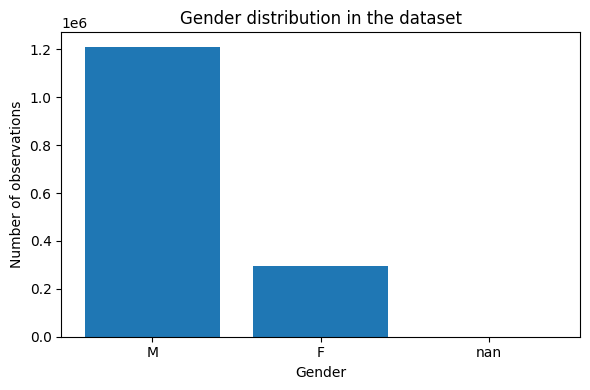

In [5]:
## Gender distribution

import matplotlib.pyplot as plt

gender_counts = (
    df["gender"]
    .value_counts(dropna=False)
    .reset_index(name="N")
    .rename(columns={"gender": "Gender"})
)


plt.figure(figsize=(6, 4))

plt.bar(
    gender_counts["Gender"].astype(str),
    gender_counts["N"]
)

plt.xlabel("Gender")
plt.ylabel("Number of observations")
plt.title("Gender distribution in the dataset")
plt.tight_layout()

plt.show()

In [6]:
#### are the names unique

director_name_check = (
    df.groupby("directorname")["directorid"]
    .nunique()
    .reset_index(name="n_unique_names")
    .sort_values("n_unique_names", ascending=False)
)

director_name_check.head(20)

,directorname,n_unique_names
218255,Morten Nielsen,15
177510,Lars Hansen,13
150407,Jens Hansen,13
12126,Anders Jensen,13
177595,Lars Jensen,13
12149,Anders Karlsson,12
154634,Johan Andersson,12
177602,Lars Johansson,12
290896,Thomas Müller,12
278515,Stefan Müller,11


In [7]:
df[df["directorname"].str.contains("Morten Nielsen", case=False, na=False)]

,directorid,directorname,companyid,companyname,gender,female,datestartrole,dateendrole,rolename,rolename_clean,...,sector_company,orgtype_company,cccountryname,fulltextdescription,num_qualifications,qualifications_raw,has_mba,has_phd,has_master,has_bachelor
112413,1094794,Morten Nielsen,22606,NOVO-NORDISK A/S,M,0.0,2015-09-01,2020-04-28,Division Senior VP,division senior vp,...,Pharmaceuticals and Biotechnology,Quoted,Denmark,Diabetes API in USA,1.0,Bachelor's Degree,0.0,0.0,0.0,1.0
150527,1892681,Morten Nielsen,29759,SYDBANK A/S,M,0.0,2019-11-01,2024-09-28,Head of Digital,head of digital,...,Banks,Quoted,Denmark,and Support,NaN,NaN,NaN,NaN,NaN,NaN
150528,1892681,Morten Nielsen,29759,SYDBANK A/S,M,0.0,2017-04-01,2019-11-28,Head of Corporate Clients,head of corporate clients,...,Banks,Quoted,Denmark,NaN,NaN,NaN,NaN,NaN,NaN,NaN
210673,2105602,Morten Nielsen,42945,Nykredit A/S (Formerly known as Nykredit Holdi...,M,0.0,2011-06-01,9000-01-01,Head of Investor Relations,head of investor relations,...,Speciality & Other Finance,Private,NaN,ALM Since May 2021,3.0,Accelerated Development Programme (ADP); Atten...,0.0,0.0,1.0,0.0
229920,2105602,Morten Nielsen,52048,Association of Danish Mortgage Banks,M,0.0,1900-01-01,9999-12-31,Various Positions,various positions,...,Business Services,Clubs,Unknown,NaN,3.0,Accelerated Development Programme (ADP); Atten...,0.0,0.0,1.0,0.0
382859,1075225,Morten Nielsen,600338,Weibel Scientific A/S,M,0.0,2025-09-01,9000-01-01,CFO,cfo,...,Electronic & Electrical Equipment,Private,Unknown,NaN,2.0,BSc; MSc,0.0,0.0,1.0,1.0
469348,2123975,Morten Nielsen,886155,AKVA GROUP ASA,M,0.0,2016-08-01,2020-10-13,Division Chief Operations Officer,division chief operations officer,...,Food Producers & Processors,Quoted,NaN,Land Based Technology,1.0,MS,0.0,0.0,0.0,0.0
509231,1753319,Morten Nielsen,1000262,Medicom Innovation Partner A/S (Bang & Olufsen...,M,0.0,2011-01-01,2018-07-28,CEO,ceo,...,Health,Private,Unknown,NaN,2.0,Graduated; Masters Degree,0.0,0.0,1.0,0.0
522431,1892681,Morten Nielsen,1020705,Nordea Bank Danmark A/S,M,0.0,2005-01-01,2017-12-28,Operations Officer,operations officer,...,Banks,Private,Unknown,NaN,NaN,NaN,NaN,NaN,NaN,NaN
544306,2865762,Morten Nielsen,1062004,Westpack A/S,M,0.0,1900-01-01,9000-01-01,CEO,ceo,...,Containers & Packaging,Private,Unknown,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
# Rows before filtering
rows_before = len(df)

# Count rows that will be removed
missing_gender_rows = df["gender"].isna().sum()
not_fm_gender_rows = (~df["gender"].isin(["F", "M"]) & df["gender"].notna()).sum()

# Remove rows where gender is missing
df = df[df["gender"].notna()].copy()

# Keep only female and male
df = df[df["gender"].isin(["F", "M"])].copy()

# Rows after filtering
rows_after = len(df)
rows_removed = rows_before - rows_after

print("Rows before filtering:", rows_before)
print("Rows removed because gender is missing:", missing_gender_rows)
print("Rows removed because gender is not F or M:", not_fm_gender_rows)
print("Total rows removed:", rows_removed)
print("Rows after filtering:", rows_after)

Rows before filtering: 1507568
Rows removed because gender is missing: 7
Rows removed because gender is not F or M: 0
Total rows removed: 7
Rows after filtering: 1507561


In [9]:
# Rows before filtering
rows_before = len(df)

# Convert datestartrole to datetime
df["datestartrole"] = pd.to_datetime(df["datestartrole"], errors="coerce")

# Count rows that will be removed
missing_start_rows = df["datestartrole"].isna().sum()
placeholder_start_rows = (df["datestartrole"] == pd.Timestamp("1900-01-01")).sum()

# Remove rows where datestartrole is missing
df = df[df["datestartrole"].notna()].copy()

# Remove placeholder start dates
df = df[df["datestartrole"] != pd.Timestamp("1900-01-01")].copy()

# Rows after filtering
rows_after = len(df)
rows_removed = rows_before - rows_after

print("Rows before filtering:", rows_before)
print("Rows removed because datestartrole is missing:", missing_start_rows)
print("Rows removed because datestartrole is 1900-01-01:", placeholder_start_rows)
print("Total rows removed:", rows_removed)
print("Rows after filtering:", rows_after)

Rows before filtering: 1507561
Rows removed because datestartrole is missing: 0
Rows removed because datestartrole is 1900-01-01: 475818
Total rows removed: 475818
Rows after filtering: 1031743


In [10]:
# Count how many rows each directorid has
df["directorid_row_count"] = df.groupby("directorid")["directorid"].transform("count")

# Weight each row inversely proportional to the number of rows for the same director
df["directorid_weight"] = 1 / df["directorid_row_count"]

df[["directorid", "directorid_row_count", "directorid_weight"]].head(20)

,directorid,directorid_row_count,directorid_weight
3,1321349,3,0.333333
7,1383365,2,0.500000
8,2297275,1,1.000000
9,626760,12,0.083333
10,5344,12,0.083333
11,5344,12,0.083333
17,502225,11,0.090909
18,58687,14,0.071429
19,58687,14,0.071429
20,58687,14,0.071429


,country,count,percent
0,Germany,121911,11.82
1,France,114018,11.05
2,United States,101788,9.87
3,Sweden,83206,8.06
4,United Kingdom - England,74646,7.23
5,Switzerland,55399,5.37
6,Italy,51045,4.95
7,Netherlands,43313,4.20
8,Norway,40712,3.95
9,Finland,35181,3.41


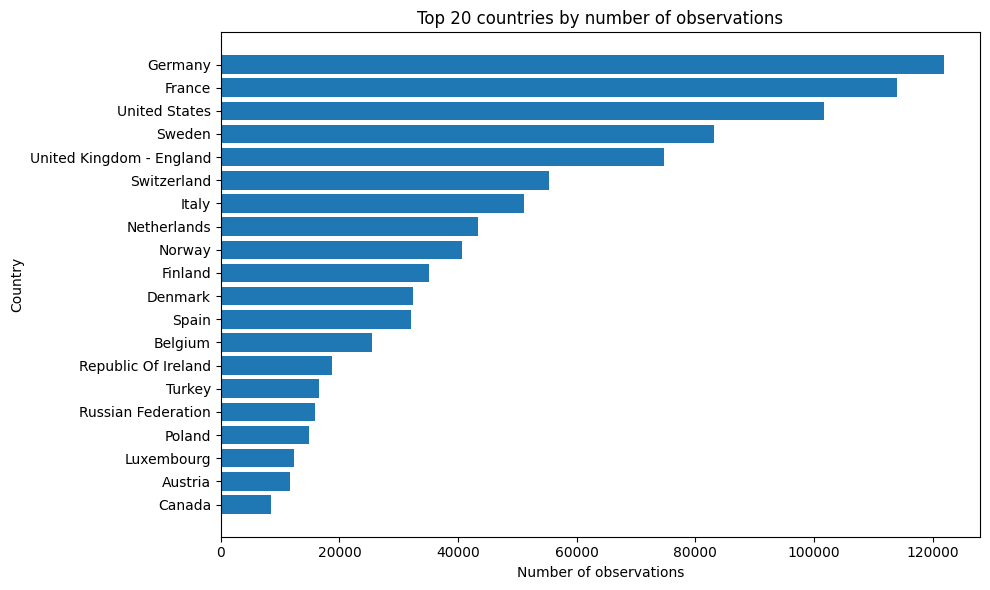

In [11]:
if "hocountryname" in df.columns:
    country_col = "hocountryname"

elif "cccountryname" in df.columns:
    country_col = "cccountryname"

else:
    raise ValueError("No country column found. Check whether your country variable is called hocountryname or cccountryname.")

# Country distribution

country_distribution = (
    df[country_col]
    .fillna("Missing")
    .value_counts()
    .reset_index()
)

country_distribution.columns = ["country", "count"]

country_distribution["percent"] = (
    country_distribution["count"] / country_distribution["count"].sum() * 100
).round(2)

display(country_distribution.head(20))

# Plot top 20 countries

top_n = 20
top_countries = country_distribution.head(top_n)

plt.figure(figsize=(10, 6))
plt.barh(top_countries["country"][::-1], top_countries["count"][::-1])
plt.xlabel("Number of observations")
plt.ylabel("Country")
plt.title(f"Top {top_n} countries by number of observations")
plt.tight_layout()

plt.show()

In [12]:
import pandas as pd

today = pd.Timestamp.today().normalize()

# make it string only for detecting placeholders
dateendrole_str = df["dateendrole"].astype(str).str.strip()

mask_placeholder = (
    dateendrole_str.str.startswith("9000-01-01") |
    dateendrole_str.str.startswith("9999-12-31")
)

# replace placeholders directly in the original column
df.loc[mask_placeholder, "dateendrole"] = today

# convert the original column to datetime
df["dateendrole"] = pd.to_datetime(df["dateendrole"], errors="coerce")

print("Replaced placeholders:", mask_placeholder.sum())
print("Missing dateendrole after replacement:", df["dateendrole"].isna().sum())

date_cols = ["datestartrole", "dateendrole"]

print(df[date_cols].value_counts(dropna=False).head(-50))


Replaced placeholders: 445436
Missing dateendrole after replacement: 0
datestartrole  dateendrole
2022-01-01     2026-06-30     9251
2023-01-01     2026-06-30     8879
2021-01-01     2026-06-30     8264
2020-01-01     2026-06-30     7918
2019-01-01     2026-06-30     7749
                              ... 
2015-06-29     2018-10-01        1
               2018-11-12        1
               2019-03-28        1
               2019-04-01        1
               2019-05-25        1
Name: count, Length: 226682, dtype: int64


In [13]:
import numpy as np
import pandas as pd

# 1. Missing data percentage before imputation
print("Missing data percentage BEFORE imputation:")
print(
    df.isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .round(2)
)

# 2. Create missingness flags BEFORE imputing

# Individual missingness flags
if "nationality" in df.columns:
    df["nationality_missing"] = df["nationality"].isna().astype(int)
else:
    df["nationality_missing"] = 0
    print("Warning: nationality column not found.")

if "cccountryname" in df.columns:
    df["cccountryname_missing"] = df["cccountryname"].isna().astype(int)
else:
    df["cccountryname_missing"] = 0
    print("Warning: cccountryname column not found.")

if "age" in df.columns:
    df["age_missing"] = df["age"].isna().astype(int)
else:
    df["age_missing"] = 0
    print("Warning: age column not found.")

# Other feature missing flag
main_missing_cols = ["nationality", "cccountryname", "age"]

flag_cols = [
    "nationality_missing",
    "cccountryname_missing",
    "age_missing",
    "other_feature_missing"
]

exclude_cols = main_missing_cols + flag_cols

other_missing_cols = [
    col for col in df.columns
    if col not in exclude_cols
]

df["other_feature_missing"] = df[other_missing_cols].isna().any(axis=1).astype(int)

# 3. Print missingness flag summaries
missing_flags = [
    "nationality_missing",
    "cccountryname_missing",
    "age_missing",
    "other_feature_missing"
]

missing_flag_summary = pd.DataFrame({
    "flag": missing_flags,
    "rows_with_missing": [df[col].sum() for col in missing_flags],
    "percent_of_dataset": [
        round(100 * df[col].sum() / len(df), 2)
        for col in missing_flags
    ]
})

display(missing_flag_summary)

for col in missing_flags:
    print(f"\n{col}")
    display(df[col].value_counts().reset_index(name="N"))

# 4. Identify column types
numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object", "string", "category"]).columns.tolist()
bool_cols = df.select_dtypes(include=["bool"]).columns.tolist()

# Do not impute the missingness flags themselves
numeric_cols = [col for col in numeric_cols if col not in missing_flags]

print("\nNumeric columns:", len(numeric_cols))
print("Categorical columns:", len(categorical_cols))
print("Boolean columns:", len(bool_cols))

# 5. Median imputation for numeric columns
for col in numeric_cols:
    if df[col].isna().any():
        median_value = df[col].median()
        df[col] = df[col].fillna(median_value)

# 6. Missing category for character/categorical columns
for col in categorical_cols:
    if df[col].isna().any():
        df[col] = df[col].fillna("Missing")

# 7. Mode imputation for boolean columns
for col in bool_cols:
    if df[col].isna().any():
        mode_value = df[col].mode(dropna=True)
        if len(mode_value) > 0:
            df[col] = df[col].fillna(mode_value.iloc[0])
        else:
            df[col] = df[col].fillna(False)

# 8. Check missing data after imputation
print("\nTotal remaining missing values:", df.isna().sum().sum())

Missing data percentage BEFORE imputation:
nationality                    64.71
fulltextdescription            60.33
cccountryname                  48.35
age                            39.23
sector_company                 35.91
orgtype_company                23.88
qualifications_raw             19.80
has_bachelor                   19.80
has_master                     19.80
has_phd                        19.80
has_mba                        19.80
num_qualifications             19.80
hocountryname                   0.11
orgtype                         0.11
brdposition_binary              0.06
is_advisor                      0.00
is_employee_representative      0.00
is_committee_member             0.00
is_consultant                   0.00
is_partner                      0.00
is_founder                      0.00
is_owner_investor               0.00
directorid                      0.00
is_manager_operational          0.00
is_unclassified_role            0.00
has_any_executive_role          

,flag,rows_with_missing,percent_of_dataset
0,nationality_missing,667610,64.71
1,cccountryname_missing,498832,48.35
2,age_missing,404775,39.23
3,other_feature_missing,819502,79.43



nationality_missing


,nationality_missing,N
0,1,667610
1,0,364133



cccountryname_missing


...


age_missing


,age_missing,N
0,0,626968
1,1,404775



other_feature_missing


,other_feature_missing,N
0,1,819502
1,0,212241



Numeric columns: 40
Categorical columns: 16
Boolean columns: 0

Total remaining missing values: 0


In [14]:
# Ensure both date columns are datetime
df["datestartrole"] = pd.to_datetime(df["datestartrole"], errors="coerce")
df["dateendrole"] = pd.to_datetime(df["dateendrole"], errors="coerce")

# Derive years worked in the role
df["years_worked"] = (
    (df["dateendrole"] - df["datestartrole"]).dt.days / 365.25
)

# Flag invalid negative durations
df["years_worked_negative"] = df["years_worked"] < 0

# Set negative durations to missing
df.loc[df["years_worked_negative"], "years_worked"] = np.nan

# Optional: round for easier inspection
df["years_worked"] = df["years_worked"].round(2)

print("Missing years_worked:", df["years_worked"].isna().sum())
print("Negative durations found:", df["years_worked_negative"].sum())

df[[
    "directorid",
    "datestartrole",
    "dateendrole",
    "years_worked",
    "years_worked_negative"
]].head(20)

Missing years_worked: 16
Negative durations found: 16


,directorid,datestartrole,dateendrole,years_worked,years_worked_negative
3,1321349,2018-06-01,2026-06-30,8.08,False
7,1383365,2013-05-01,2020-02-28,6.83,False
8,2297275,2020-02-01,2023-06-28,3.40,False
9,626760,1988-11-28,2026-06-30,37.59,False
10,5344,2013-11-01,2022-10-14,8.95,False
11,5344,2022-10-14,2026-06-30,3.71,False
17,502225,2020-05-06,2026-06-30,6.15,False
18,58687,2009-01-09,2016-01-20,7.03,False
19,58687,2016-09-29,2016-12-01,0.17,False
20,58687,2016-12-01,2020-07-22,3.64,False


In [15]:
# Count how many rows each gender has
df["gender_row_count"] = df.groupby("gender")["gender"].transform("count")

# Total number of rows and number of gender groups
n_total = len(df)
n_gender_groups = df["gender"].nunique()

# Gender-balance weight
df["gender_weight"] = n_total / (n_gender_groups * df["gender_row_count"])

df[["gender", "gender_row_count", "gender_weight"]].drop_duplicates().sort_values("gender")

,gender,gender_row_count,gender_weight
17,F,223149,2.311780
3,M,808594,0.637986


## 4. Planned Methods



### 4a. Causal Inference

- [x] Causal graph / DAG

- [x] Backdoor adjustment

- [ ] Instrumental variable

- [x] Propensity score stratification

- [ ] Other: ___

**Justification:**

The DAG represents the assumed pathways between gender and access to leadership roles. The variable is `female`, and the outcome is access to top roles, measured by variables such as `has_any_executive_role` or `leadershipteam_binary`.

The graph assumes that gender may be associated with access to the top positions directly, but also indirectly through career and organizational mechanisms. Education, sector, board status, role status and network positions may act as mediators.

Age, nationality, company head-office country, sector, and organization type are included as observed adjustment variables. However, these observed adjustment variables are not sufficient to remove all confounding. The variable `U` represents unobserved factors that are not presented in the dataset. These may include ambition, career preferences, family constraints, hiring culture, and board nomination practices. Because such factors are not observed, the analysis will not claim a definitive causal effect of gender. Instead, the DAG is used to make the assumptions explicit and to estimate an adjusted gender gap under these assumptions.

Additionally, we can use propensity score stratification. First, the propensity score is estimated as the probability of being recorded as female conditional on the observed adjustment variables. Individuals are then divided into strata with similar propensity scores. Within each stratum, the probability of holding a top role is compared between women and men. The final estimate is the weighted average of these specific differences within stratum. This estimate is interpreted as an adjusted gender disparity, not as a definitive causal effect.

To assess robustness, refutation tests will be implemented in DoWhy. A random common cause refuter can be used by adding a randomly generated confounder to the model. We will replace real treatment variable female with a randomly assigned placebo treatment. If the estimated effect does not change substantially, this supports the stability of the result.

### 4b. Supervised Learning
- [x] Linear / Ridge / Lasso regression
- [x] Logistic regression
- [ ] k-Nearest Neighbors
- [ ] Support Vector Machine
- [x] Decision Tree / Random Forest
- [ ] Neural network (regression or classification)
- [ ] Other: ___

*Justification:*  

Logistic regression is selected because it is interpretable and suitable for binary outcomes. The main outcome will be `has_any_executive_role`, which indicates whether a person holds a high position. Additional binary outcomes such as `leadershipteam_binary`, `is_ceo`, `is_cfo`, `is_coo`, `is_board_member_ed`, and `is_senior_management`, etc. It allows the coefficient of `female` to be interpreted as the association between gender and the probability of holding an executive or leadership role, conditional on other variables.

Lasso logistic regression will be used as a regularized version of logistic regression. It is useful because the dataset contains many binary role indicators and control variables. Lasso can shrink less important coefficients toward zero, helping with feature selection and making the model easier to interpret in the report.

Random Forest will be used as a more flexible model that can capture non-linear relationships and interactions between variables. It also provides feature importance, which is useful for identifying which variables are most relevant for predicting executive-role access.

### 4c. Unsupervised Learning / Generative Models

- [x] K-Means clustering

- [] Hierarchical clustering

- [ ] Variational autoencoder

- [ ] GAN

- [ ] Other: ___

**Justification:**

K-Means clustering is selected instead of hierarchical clustering because K-Means scales better to the size of the dataset. Even after filtering missing unusable start dates, the dataset still contains roughly one million role-level observations. K-Means has runtime that is approximately linear in the number of observations, while hierarchical clustering usually requires constructing a distance matrix and has approximately quadratic complexity in the number of observations. Therefore, hierarchical clustering would still be computationally expensive and may not run reliably.

The clustering will be applied to variables that describe the individual and organizational context but do not directly define the target outcome. These include age, nationality, company head-office country, organization type, sector, education, board status, committee membership, and other non-executive role context indicators. Outcome variables such as `has_any_executive_role`, `leadershipteam_binary`, and the top role indicators will not be used for clustering if the resulting cluster labels are later used in supervised models, in order to avoid target leakage.

After clusters are created, the gender distribution and the distribution of education, board status, sector, and organization type within each cluster will be compared. This allows the clusters to be interpreted as meaningful groups rather than only technical outputs of the clustering algorithm.

The clustering block is connected to the supervised learning block by using the cluster identities as additional features. Supervised models will first be trained without cluster labels and then with cluster labels. Comparing model performance across these specifications, using metrics such as AUC, F1-score, precision, and recall, will show whether the unsupervised latent groups provide additional predictive information for access to top executive roles.

Finally, the clusters can help the causal analysis in exploring heterogeneous effects. The project can test whether the gender gap is stronger in some clusters than in others by comparing the association between `female` and `has_any_executive_role` within different clusters.

## 5. Evaluation Strategy


The mission will be considered successful if the analysis can identify and explain gender differences in access to the high positions in the companies.

In the casual inference part, to assess robustness, refutation tests will be implemented in DoWhy. A random common cause refuter can be used by adding a randomly generated confounder to the model.

For supervised learning, the models will be evaluated using cross-validation. Logistic regression, Lasso logistic regression, and Random Forest will be compared using the same main evaluation metrics: accuracy, precision, recall, F1-score, and AUC. AUC and F1-score will be especially important, because there is a data imbalance. A simple baseline model, such as predicting the majority class, will be used as a benchmark.

Logistic regression will be used as the main interpretable model. Lasso logistic regression will be compared to logistic regression to check whether regularization and feature selection improve the performance. Random Forest will be compared to both to test whether it improves predictive performance.

K-Means clustering will be evaluated using inertia and the elbow method to choose the number of clusters. If possible, silhouette score will also be calculated on a subsample.

The clusters will be interpreted by comparing gender shares, sector, organization type, board status, and executive-role rates across clusters. A PCA plot can be used to visualize the clusters.



## 6. Work Plan

| Step | Owner | Description                     |
|------|-------|---------------------------------|
| 1 | Emma  | Data collection & cleaning      |
| 2 | Emma  | EDA                             |
| 3 | Mohamed & Ahmed  | Causal inference block          |
| 4 | Mohamed  | Supervised learning block       |
| 5 | Ahmed  | Unsupervised / generative block |
| 6 | Emma  | Synthesis & write-up            |


In [16]:
# Save the cleaned dataset for the modelling sections

df.to_csv("data_clean.csv", index=False)

print("data_clean.csv saved successfully!")
print(df.shape)

data_clean.csv saved successfully!
(1031743, 66)


### 7a. Causal Inference

We estimate the **adjusted gender disparity** in access to top roles.

- **Treatment:** `female` (1 = female, 0 = male)
- **Outcome:** `has_any_executive_role`
- **Adjustment set (observed confounders):** `age`, `nationality`, `hocountryname`,
  `orgtype_company`, `sector_company`
- **Deliberately NOT adjusted (mediators):** education, board status, role status, network —
  so the estimate is the **total** effect of gender, not a partial/post-mediator one.

**Pipeline:** assumed DAG → naive gap → backdoor adjustment (DoWhy: linear regression &
propensity-score stratification) → manual propensity-score stratification with 95% CI + IPW
cross-check → refutation tests (random common cause, placebo treatment, data subset).

Because unobserved factors (`U`: ambition, family constraints, hiring/nomination culture, …)
are not in the data, this is interpreted as an **adjusted disparity under
selection-on-observables, not a definitive causal effect**.

> Requires `dowhy`, `scikit-learn`, `networkx` (`pip install dowhy scikit-learn networkx`).

In [17]:
import os, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
RNG = 42

TREAT, OUTCOME = "female", "has_any_executive_role"
CONF_NUM = ["age"]                          # numeric confounder
CONF_BIN = ["age_missing"]                  # missing-indicator (informative missingness, Kira #1)
CONF_CAT = ["nationality", "hocountryname", "orgtype_company", "sector_company"]
NEEDED = ["female", "gender", OUTCOME, "age", "age_missing"] + CONF_CAT

if "df" in globals():
    df_c = df[[c for c in NEEDED if c in df.columns]].copy()      # reuse Emma's cleaned dataframe
else:                                                             # fallback: self-contained load
    CANDIDATES = ["data.csv", r"C:\Users\moham\Downloads\DAI\data.csv", "/content/data.csv"]
    DATA = next((p for p in CANDIDATES if os.path.exists(p)), CANDIDATES[0])
    df_c = pd.read_csv(DATA, usecols=["gender", "datestartrole", OUTCOME, "age"] + CONF_CAT)
    df_c = df_c[df_c["gender"].isin(["F", "M"])].copy()
    df_c["datestartrole"] = pd.to_datetime(df_c["datestartrole"], errors="coerce")
    df_c = df_c[df_c["datestartrole"].notna()]
    df_c = df_c[df_c["datestartrole"] != pd.Timestamp("1900-01-01")].copy()

# Treatment / outcome as clean integers
df_c["female"] = (df_c["female"] if "female" in df_c.columns else (df_c["gender"] == "F")).astype(int)
df_c[OUTCOME] = pd.to_numeric(df_c[OUTCOME], errors="coerce")
df_c = df_c[df_c[OUTCOME].notna()].copy()
df_c[OUTCOME] = df_c[OUTCOME].astype(int)

# Missing-data strategy
df_c["age"] = pd.to_numeric(df_c["age"], errors="coerce")
if "age_missing" not in df_c.columns:
    df_c["age_missing"] = df_c["age"].isna().astype(int)
df_c["age_missing"] = df_c["age_missing"].astype(int)
df_c["age"] = df_c["age"].fillna(df_c["age"].median())
for c in CONF_CAT:
    df_c[c] = df_c[c].astype("object").fillna("Missing")

# Reduce cardinality of categorical confounders (top-15 + "Other")
def top_k(s, k=15):
    keep = s.value_counts().head(k).index
    return s.where(s.isin(keep), "Other")
for c in CONF_CAT:
    df_c[c] = top_k(df_c[c], 15)

print("Rows used         :", len(df_c))
print("Female share      :", round(df_c[TREAT].mean(), 4))
print("Exec-role share   :", round(df_c[OUTCOME].mean(), 4))
print("Age-missing share :", round(df_c["age_missing"].mean(), 4))

Rows used         : 1031743
Female share      : 0.2163
Exec-role share   : 0.3314
Age-missing share : 0.3923


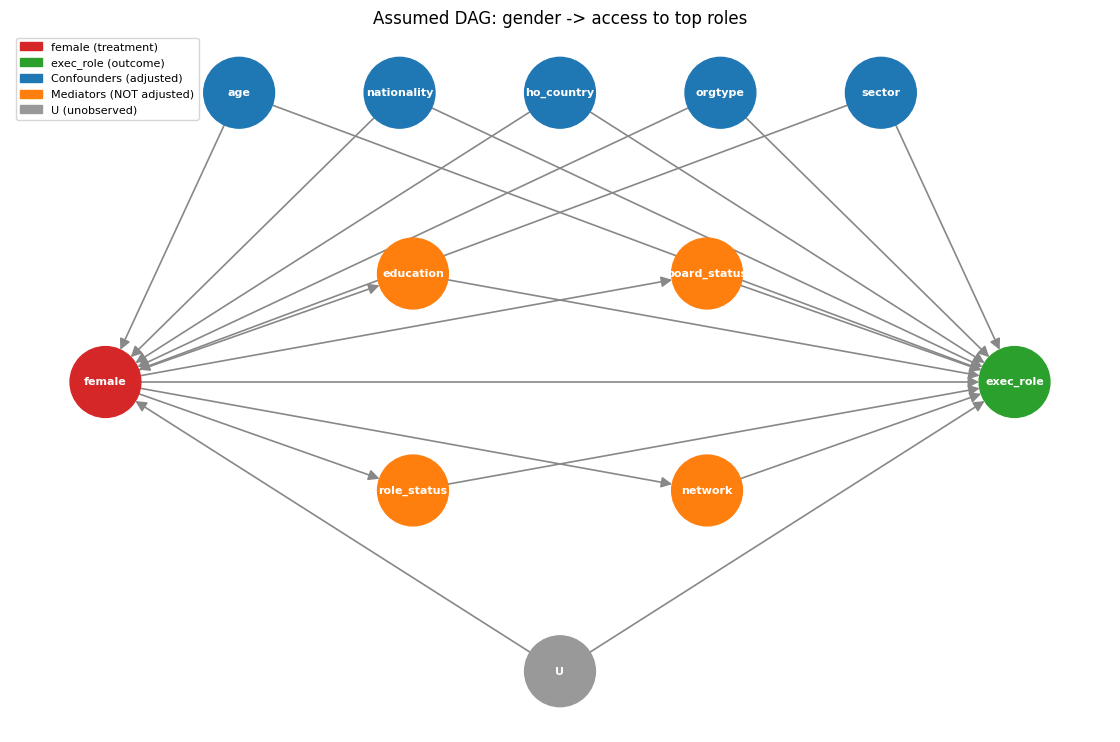

In [18]:
# --- Assumed causal graph (DAG) ---
import networkx as nx
from matplotlib.patches import Patch

conf = ["age", "nationality", "ho_country", "orgtype", "sector"]
med  = ["education", "board_status", "role_status", "network"]

edges = []
for c in conf:
    edges += [(c, "female"), (c, "exec_role")]
for m in med:
    edges += [("female", m), (m, "exec_role")]
edges += [("female", "exec_role"), ("U", "female"), ("U", "exec_role")]
G = nx.DiGraph(edges)

pos = {
    "female": (-3.4, 0), "exec_role": (3.4, 0),
    "age": (-2.4, 2.4), "nationality": (-1.2, 2.4), "ho_country": (0, 2.4),
    "orgtype": (1.2, 2.4), "sector": (2.4, 2.4),
    "education": (-1.1, 0.9), "board_status": (1.1, 0.9),
    "role_status": (-1.1, -0.9), "network": (1.1, -0.9),
    "U": (0, -2.4),
}

def _color(n):
    if n == "female":    return "#d62728"   # treatment (red)
    if n == "exec_role": return "#2ca02c"   # outcome (green)
    if n == "U":         return "#999999"   # unobserved (grey)
    if n in conf:        return "#1f77b4"   # confounder (blue)
    return "#ff7f0e"                         # mediator (orange)

plt.figure(figsize=(11, 7))
nx.draw(G, pos, with_labels=True, node_color=[_color(n) for n in G.nodes()],
        node_size=2600, font_size=8, font_color="white", font_weight="bold",
        arrowsize=16, edge_color="#888", width=1.2)
plt.legend(handles=[
    Patch(color="#d62728", label="female (treatment)"),
    Patch(color="#2ca02c", label="exec_role (outcome)"),
    Patch(color="#1f77b4", label="Confounders (adjusted)"),
    Patch(color="#ff7f0e", label="Mediators (NOT adjusted)"),
    Patch(color="#999999", label="U (unobserved)"),
], loc="upper left", fontsize=8, frameon=True)
plt.title("Assumed DAG: gender -> access to top roles")
plt.show()

In [19]:
# --- Naive (unadjusted) gender gap ---
naive_gap = (df_c.loc[df_c[TREAT] == 1, OUTCOME].mean()
             - df_c.loc[df_c[TREAT] == 0, OUTCOME].mean())
print("P(exec | female) :", round(df_c.loc[df_c[TREAT] == 1, OUTCOME].mean(), 4))
print("P(exec | male)   :", round(df_c.loc[df_c[TREAT] == 0, OUTCOME].mean(), 4))
print("Naive gap (F - M):", round(naive_gap, 4))

P(exec | female) : 0.3116
P(exec | male)   : 0.3369
Naive gap (F - M): -0.0253


In [20]:
# --- Propensity score estimation + stratification (full data) ------------
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Design matrix: age + age_missing indicator + one-hot categorical confounders
X_cat = pd.get_dummies(df_c[CONF_CAT].astype(str), drop_first=True)
X = pd.concat([df_c[CONF_NUM + CONF_BIN].reset_index(drop=True),
               X_cat.reset_index(drop=True)], axis=1).astype(float)

Xs = X.copy()
Xs["age"] = StandardScaler().fit_transform(Xs[["age"]])
df_c["ps"] = (LogisticRegression(max_iter=1000)
              .fit(Xs, df_c[TREAT].values)
              .predict_proba(Xs)[:, 1])

# Trim to the region of common support (overlap)
lo = max(df_c.loc[df_c[TREAT] == 1, "ps"].min(), df_c.loc[df_c[TREAT] == 0, "ps"].min())
hi = min(df_c.loc[df_c[TREAT] == 1, "ps"].max(), df_c.loc[df_c[TREAT] == 0, "ps"].max())
ds = df_c[(df_c["ps"] >= lo) & (df_c["ps"] <= hi)].copy()

# 10 strata by propensity-score deciles; within-stratum F-M gap, then weighted avg
ds["stratum"] = pd.qcut(ds["ps"], 10, labels=False, duplicates="drop")
rows, num, den, var = [], 0.0, 0.0, 0.0
for s, g in ds.groupby("stratum"):
    f, m = g[g[TREAT] == 1], g[g[TREAT] == 0]
    if len(f) == 0 or len(m) == 0:
        continue
    diff, w = f[OUTCOME].mean() - m[OUTCOME].mean(), len(g)
    num += diff * w
    den += w
    var += (w ** 2) * (f[OUTCOME].var(ddof=1) / len(f) + m[OUTCOME].var(ddof=1) / len(m))
    rows.append([int(s), len(f), len(m), round(f[OUTCOME].mean(), 3),
                 round(m[OUTCOME].mean(), 3), round(diff, 4)])

strat_tbl = pd.DataFrame(rows, columns=["stratum", "n_F", "n_M", "exec_F", "exec_M", "gap"])
ate, se = num / den, np.sqrt(var) / den
display(strat_tbl)
print("PS-stratified adjusted gap: %.4f  (95%% CI %.4f .. %.4f)"
      % (ate, ate - 1.96 * se, ate + 1.96 * se))

# IPW cross-check
e = np.clip(ds["ps"].values, 0.01, 0.99)
t, y = ds[TREAT].values, ds[OUTCOME].values
w_ipw = np.where(t == 1, 1 / e, 1 / (1 - e))
ate_ipw = (np.sum(w_ipw * t * y) / np.sum(w_ipw * t)
           - np.sum(w_ipw * (1 - t) * y) / np.sum(w_ipw * (1 - t)))
print("IPW adjusted gap (cross-check):", round(ate_ipw, 4))

,stratum,n_F,n_M,exec_F,exec_M,gap
0,0,8408,95022,0.157,0.188,-0.0302
1,1,14748,88177,0.223,0.289,-0.0657
2,2,18151,85018,0.259,0.321,-0.0617
3,3,22923,94763,0.314,0.368,-0.0543
4,4,19068,70667,0.318,0.375,-0.0577
5,5,26963,87854,0.318,0.361,-0.0438
6,6,21961,70015,0.338,0.369,-0.0307
7,7,27576,76808,0.329,0.367,-0.0376
8,8,28618,71844,0.342,0.386,-0.0440
9,9,34729,68426,0.349,0.394,-0.0449


PS-stratified adjusted gap: -0.0472  (95% CI -0.0494 .. -0.0450)
IPW adjusted gap (cross-check): -0.0446


In [21]:
# --- Backdoor adjustment with DoWhy + refutation tests ---
from dowhy import CausalModel

samp = df_c.sample(n=min(120_000, len(df_c)), random_state=RNG).reset_index(drop=True)
dw = pd.concat(
    [samp[[TREAT, OUTCOME] + CONF_NUM + CONF_BIN].reset_index(drop=True),
     pd.get_dummies(samp[CONF_CAT].astype(str), drop_first=True).reset_index(drop=True)],
    axis=1,
)
dw[TREAT] = dw[TREAT].astype(int)
common = [c for c in dw.columns if c not in (TREAT, OUTCOME)]

model = CausalModel(data=dw, treatment=TREAT, outcome=OUTCOME, common_causes=common)
identified = model.identify_effect(proceed_when_unidentifiable=True)

# Backdoor adjustment, two estimators
est_lr = model.estimate_effect(identified,
                               method_name="backdoor.linear_regression",
                               target_units="ate")
est_ps = model.estimate_effect(identified,
                               method_name="backdoor.propensity_score_stratification",
                               target_units="ate")
print("DoWhy backdoor (linear regression) ATE :", round(est_lr.value, 4))
print("DoWhy backdoor (PS stratification) ATE :", round(est_ps.value, 4))

# Refutation tests
print("\n--- Refutation tests ---")
r1 = model.refute_estimate(identified, est_ps,
                           method_name="random_common_cause", num_simulations=5)
print("Random common cause   -> new effect:", round(r1.new_effect, 4),
      "(should stay close to the estimate)")
r2 = model.refute_estimate(identified, est_ps,
                           method_name="placebo_treatment_refuter",
                           placebo_type="permute", num_simulations=5)
print("Placebo treatment     -> new effect:", round(r2.new_effect, 4),
      "(should be close to 0)")
r3 = model.refute_estimate(identified, est_ps,
                           method_name="data_subset_refuter",
                           subset_fraction=0.8, num_simulations=5)
print("Data subset (80%)     -> new effect:", round(r3.new_effect, 4),
      "(should stay close to the estimate)")

DoWhy backdoor (linear regression) ATE : -0.0469
DoWhy backdoor (PS stratification) ATE : -0.0455

--- Refutation tests ---
Random common cause   -> new effect: -0.0455 (should stay close to the estimate)
Placebo treatment     -> new effect: 0.0007 (should be close to 0)
Data subset (80%)     -> new effect: -0.0443 (should stay close to the estimate)


### Interpretation

**Treatment** `female`, **outcome** `has_any_executive_role`. We adjust **only for observed confounders**
(age, an age missing-indicator, nationality, head-office country, organization type, sector) and
deliberately **leave out mediators** (education, board status, role status, network), so the estimate is
the *total* gender disparity, not a post-mediator effect.

**Missing-data strategy (addressing the feedback).**
- **Categorical confounders:** missing values are kept as a deliberate, informative **"Missing" category**
  (not dropped) so no rows are lost to selection bias.
- **age (~37-39% missing):** we add an informative **`age_missing` indicator** to the adjustment set and
  then median-impute the value. Conditioning on the *pattern* of missingness — not just the filled value —
  is what closes the backdoor path. Including it moved the adjusted gap from about -4.1 pp to about -4.7 pp,
  i.e. the missingness itself was informative.
- **education (~80% missing)** is a **mediator**, so it is *not* in the adjustment set at all — its heavy
  missingness therefore never biases the backdoor adjustment.

**Results.**
- **Naive (unadjusted) gap ~ -2.5 pp** -- women ~2.5 pp less likely to hold a top role.
- **After backdoor / propensity-score adjustment the gap widens to ~ -4.7 pp** (PS-stratification, DoWhy
  linear-regression and PS-stratification all agree, with IPW as a cross-check). Observed confounders were
  *masking* part of the disparity, so adjusting reveals a larger within-stratum gap.
- The gap is **negative and fairly stable across all propensity-score strata**.

**Robustness (DoWhy refuters).**
- *Random common cause* -- adding a random confounder leaves the estimate ~unchanged -> stable.
- *Placebo treatment* (permuted `female`) -- effect collapses to ~0 -> not a procedural artefact.
- *Data subset (80%)* -- estimate barely moves -> not driven by a small subsample.

**Caveat.** This is an **adjusted gender disparity under selection-on-observables**, *not* a definitive
causal effect. The node `U` (ambition, family constraints, hiring/nomination culture, ...) is unobserved,
so residual confounding cannot be ruled out.

## 7b. Supervised Learning

Predict **access to a top role** and quantify how much `female` contributes once other
characteristics are accounted for.

- **Outcome:** `has_any_executive_role` (binary; base rate ~ 33%)
- **Features:** `female`, `age`, education (`num_qualifications`, `has_mba/phd/master/bachelor`
  + a missingness flag), board/committee/role context (`ned_binary`, `brdposition_binary`,
  `is_chairman`, `is_partner`, `is_advisor`, ...), and one-hot `nationality`, `hocountryname`,
  `orgtype_company`, `sector_company` (top-15 + "Other").
- **Leakage control:** the executive-defining role flags (`is_ceo`, `is_cfo`, `is_executive`, ...)
  are **excluded** -- `has_any_executive_role` is essentially their OR, so keeping them is circular.

**Models:** majority-class **baseline**, **Logistic regression**, **Lasso logistic** (L1, feature
selection), **Random Forest**. **Evaluation:** 5-fold stratified cross-validation on accuracy /
precision / recall / F1 / ROC-AUC, plus a held-out test set with ROC curves.

**Rigour (addressing the execution-phase feedback):**
- **No data leakage:** all median imputation + scaling are fit **inside** each CV fold via a
  `Pipeline` (never on the held-out data), so the reported metrics are not over-optimistic.
- **Class imbalance:** handled algorithmically with `class_weight="balanced"` in every model.
- **Panel structure (non-i.i.d.):** the gender coefficient is reported with **standard errors
  clustered on `directorid`** (multiple role-rows per director), giving honest confidence intervals.

> Requires `scikit-learn` and `statsmodels`. Models run on a stratified sample (RF is heavy on ~1M rows).

In [22]:
import os, gc, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")
RNG = 42

DATA = "data.csv"

TARGET = "has_any_executive_role"
NUM = ["age", "num_qualifications"]                    # median-imputed + scaled INSIDE folds
EDU = ["has_mba", "has_phd", "has_master", "has_bachelor"]
BIN = ["female", "brdposition_binary", "ned_binary", "is_chairman", "is_board_member_sd",
       "is_board_member_ed", "is_ned", "is_independent_director", "is_nonexecutive_independent",
       "is_committee_member", "is_advisor", "is_consultant", "is_partner", "is_founder",
       "is_owner_investor", "is_employee_representative", "is_manager_operational"]
CAT = ["nationality", "hocountryname", "orgtype_company", "sector_company"]

USECOLS = (["directorid", "gender", "datestartrole", TARGET] + NUM + EDU
           + [c for c in BIN if c != "female"] + CAT)
df_s = pd.read_csv(DATA, usecols=USECOLS)

df_s = df_s[df_s["gender"].isin(["F", "M"])].copy()
df_s["female"] = (df_s["gender"] == "F").astype(int)
df_s["datestartrole"] = pd.to_datetime(df_s["datestartrole"], errors="coerce")
df_s = df_s[df_s["datestartrole"].notna()]
df_s = df_s[df_s["datestartrole"] != pd.Timestamp("1900-01-01")].copy()
df_s[TARGET] = pd.to_numeric(df_s[TARGET], errors="coerce")
df_s = df_s[df_s[TARGET].notna()].copy()
df_s[TARGET] = df_s[TARGET].astype(int)


df_s["edu_missing"] = df_s["num_qualifications"].isna().astype(int)   # informative flag
for c in NUM:
    df_s[c] = pd.to_numeric(df_s[c], errors="coerce")                 # KEEP NaN -> imputed in-fold
for c in EDU + [b for b in BIN if b != "female"]:
    df_s[c] = pd.to_numeric(df_s[c], errors="coerce").fillna(0)       # constant fill -> no leakage
for c in CAT:
    df_s[c] = df_s[c].astype("object").fillna("Missing")
def top_k(s, k=15):
    keep = s.value_counts().head(k).index
    return s.where(s.isin(keep), "Other")
for c in CAT:
    df_s[c] = top_k(df_s[c], 15)

# Stratified sample BEFORE building the design matrix
samp = train_test_split(df_s, train_size=200_000, stratify=df_s[TARGET], random_state=RNG)[0]
samp = samp.reset_index(drop=True)
del df_s
gc.collect()

# RAW design matrix on the sample: numerics keep NaN (imputed later, in-fold); rest deterministic.
X_cat = pd.get_dummies(samp[CAT].astype(str), drop_first=True).astype("float32")
X_s = pd.concat([samp[NUM].astype("float32"),
                 samp[BIN + EDU + ["edu_missing"]].astype("float32"),
                 X_cat], axis=1)
y_s = samp[TARGET].values
groups_all = samp["directorid"].values            # used for clustered standard errors
print("Design matrix (200k stratified sample):", X_s.shape,
      "| target rate:", round(y_s.mean(), 4))

Design matrix (200k stratified sample): (200000, 79) | target rate: 0.3314


In [23]:
# --- Leakage-safe model comparison: preprocessing fitted INSIDE each fold ---
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

Xs_feat, ys = X_s, y_s          # the 200k stratified sample built above

# numeric columns get median-impute + scale WITHIN the pipeline => computed in-fold only
pre = ColumnTransformer(
    [("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                       ("sc", StandardScaler())]), NUM)],
    remainder="passthrough")
def make(model):
    return Pipeline([("pre", pre), ("clf", model)])

models = {
    "Baseline (majority)": make(DummyClassifier(strategy="most_frequent")),
    "Logistic": make(LogisticRegression(max_iter=1000, class_weight="balanced")),
    "Lasso Logistic": make(LogisticRegression(penalty="l1", solver="saga", C=0.1,
                                              max_iter=2000, class_weight="balanced")),
    "Random Forest": make(RandomForestClassifier(n_estimators=200, min_samples_leaf=20,
                          n_jobs=2, class_weight="balanced", random_state=RNG)),
}
scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RNG)
rows = []
for name, m in models.items():
    r = cross_validate(m, Xs_feat, ys, cv=cv, scoring=scoring, n_jobs=1)
    rows.append([name] + [f"{r['test_'+s].mean():.3f} ± {r['test_'+s].std():.3f}"
                          for s in scoring])
comparison = pd.DataFrame(rows, columns=["model"] + scoring)
display(comparison)

,model,accuracy,precision,recall,f1,roc_auc
0,Baseline (majority),0.669 ± 0.000,0.000 ± 0.000,0.000 ± 0.000,0.000 ± 0.000,0.500 ± 0.000
1,Logistic,0.767 ± 0.001,0.594 ± 0.001,0.938 ± 0.001,0.727 ± 0.001,0.858 ± 0.001
2,Lasso Logistic,0.767 ± 0.001,0.594 ± 0.001,0.938 ± 0.001,0.728 ± 0.001,0.858 ± 0.001
3,Random Forest,0.773 ± 0.001,0.599 ± 0.001,0.952 ± 0.002,0.735 ± 0.001,0.863 ± 0.001



[Logistic] held-out test AUC = 0.858
              precision    recall  f1-score   support

           0      0.954     0.684     0.797     33428
           1      0.594     0.934     0.726     16572

    accuracy                          0.767     50000
   macro avg      0.774     0.809     0.762     50000
weighted avg      0.835     0.767     0.773     50000


[Random Forest] held-out test AUC = 0.865
              precision    recall  f1-score   support

           0      0.965     0.684     0.801     33428
           1      0.599     0.950     0.735     16572

    accuracy                          0.772     50000
   macro avg      0.782     0.817     0.768     50000
weighted avg      0.844     0.772     0.779     50000



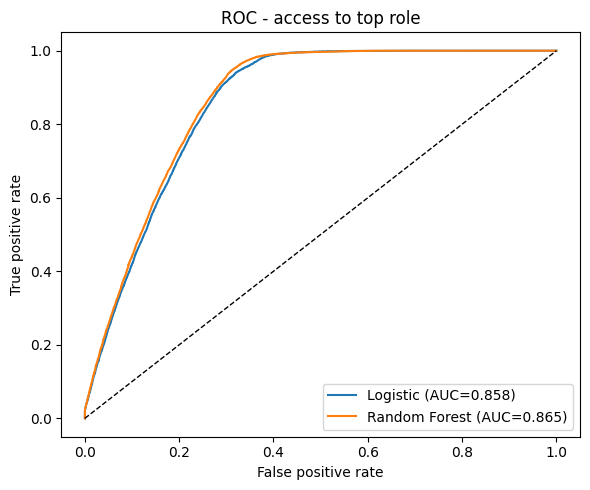

In [24]:
# --- Held-out test: fit the leakage-safe Logistic + Random Forest + ROC ---
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report, roc_curve

Xtr, Xte, ytr, yte = train_test_split(Xs_feat, ys, test_size=0.25,
                                      stratify=ys, random_state=RNG)
logit_pipe = make(LogisticRegression(max_iter=1000, class_weight="balanced")).fit(Xtr, ytr)
rf_pipe = make(RandomForestClassifier(n_estimators=200, min_samples_leaf=20, n_jobs=2,
                                      class_weight="balanced", random_state=RNG)).fit(Xtr, ytr)

plt.figure(figsize=(6, 5))
for nm, mdl in [("Logistic", logit_pipe), ("Random Forest", rf_pipe)]:
    p = mdl.predict_proba(Xte)[:, 1]
    auc = roc_auc_score(yte, p)
    fpr, tpr, _ = roc_curve(yte, p)
    plt.plot(fpr, tpr, label=f"{nm} (AUC={auc:.3f})")
    print(f"\n[{nm}] held-out test AUC = {auc:.3f}")
    print(classification_report(yte, (p >= 0.5).astype(int), digits=3))
plt.plot([0, 1], [0, 1], "k--", lw=1)
plt.xlabel("False positive rate"); plt.ylabel("True positive rate")
plt.title("ROC - access to top role"); plt.legend(); plt.tight_layout(); plt.show()

Logistic coef for 'female': -0.1873  -> odds ratio: 0.829
Lasso kept 67/79 features (zeroed 12) | coef 'female': -0.1831


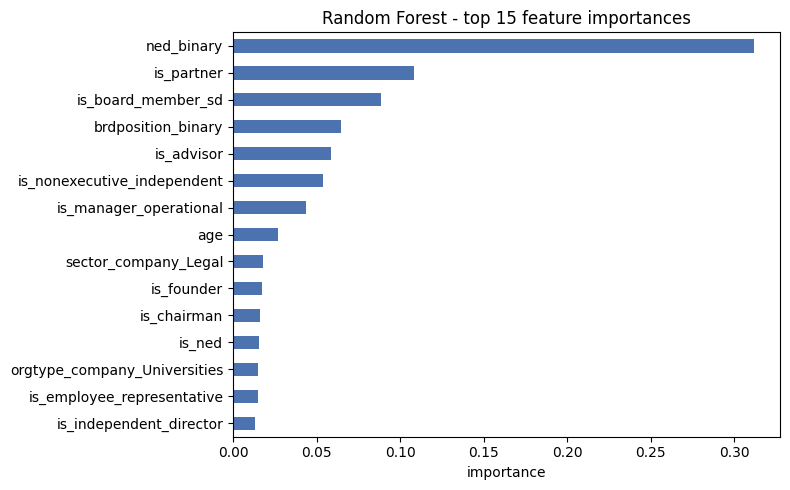


--- Gender coefficient with clustered standard errors ---
clusters (unique directors): 66581
female coef : -0.1720  (odds ratio 0.842)
classical  SE: 0.0218  -> 95% CI [-0.2147, -0.1293]
clustered  SE: 0.0224  -> 95% CI [-0.2158, -0.1281]
clustering inflates SE by 1.03x; gender stays significant (p = 1.5e-14)


In [25]:
# --- Interpretation: gender effect, drivers, and CLUSTERED standard errors ---
names = [n.split("__")[-1] for n in logit_pipe.named_steps["pre"].get_feature_names_out()]
coef = pd.Series(logit_pipe.named_steps["clf"].coef_[0], index=names)
print("Logistic coef for 'female': %.4f  -> odds ratio: %.3f"
      % (coef["female"], np.exp(coef["female"])))

# Lasso feature selection
lasso_pipe = make(LogisticRegression(penalty="l1", solver="saga", C=0.1, max_iter=2000,
                                     class_weight="balanced")).fit(Xtr, ytr)
lc = lasso_pipe.named_steps["clf"].coef_[0]
print("Lasso kept %d/%d features (zeroed %d) | coef 'female': %.4f"
      % ((np.abs(lc) > 1e-6).sum(), len(lc), (np.abs(lc) <= 1e-6).sum(),
         pd.Series(lc, index=names)["female"]))

# Random Forest feature importances
imp = pd.Series(rf_pipe.named_steps["clf"].feature_importances_,
                index=names).sort_values(ascending=False)
plt.figure(figsize=(8, 5))
imp.head(15)[::-1].plot(kind="barh", color="#4c72b0")
plt.title("Random Forest - top 15 feature importances")
plt.xlabel("importance"); plt.tight_layout(); plt.show()

# --- Clustered standard errors (panel structure: many role-rows per director) ---
import gc, statsmodels.api as sm
gc.collect()
INF = ["female", "age", "num_qualifications", "has_mba", "has_phd", "has_master",
       "has_bachelor", "edu_missing", "brdposition_binary", "ned_binary", "is_chairman",
       "is_board_member_sd", "is_nonexecutive_independent", "is_partner",
       "is_manager_operational", "is_independent_director"]
si = pd.Series(range(len(X_s))).sample(n=min(80_000, len(X_s)), random_state=RNG).values
Xinf = X_s.iloc[si][INF].astype("float64").copy()
for c in ["age", "num_qualifications"]:
    Xinf[c] = Xinf[c].fillna(Xinf[c].median())
    Xinf[c] = (Xinf[c] - Xinf[c].mean()) / Xinf[c].std()
yi = y_s[si].astype("float64"); gi = groups_all[si]
Xinf = sm.add_constant(Xinf)
m_inf = sm.Logit(yi, Xinf)
res = m_inf.fit(method="lbfgs", maxiter=500, disp=0)                       # classical SE
res_cl = m_inf.fit(method="lbfgs", maxiter=500, disp=0,
                   cov_type="cluster", cov_kwds={"groups": gi})            # clustered on director
b, se_n, se_c = res_cl.params["female"], res.bse["female"], res_cl.bse["female"]
print("\n--- Gender coefficient with clustered standard errors ---")
print("clusters (unique directors): %d" % len(np.unique(gi)))
print("female coef : %.4f  (odds ratio %.3f)" % (b, np.exp(b)))
print("classical  SE: %.4f  -> 95%% CI [%.4f, %.4f]" % (se_n, b - 1.96 * se_n, b + 1.96 * se_n))
print("clustered  SE: %.4f  -> 95%% CI [%.4f, %.4f]" % (se_c, b - 1.96 * se_c, b + 1.96 * se_c))
print("clustering inflates SE by %.2fx; gender stays significant (p = %.1e)"
      % (se_c / se_n, res_cl.pvalues["female"]))

### Interpretation

**Predictive performance (leakage-safe 5-fold CV, 150k stratified sample).**

| Model | Accuracy | F1 | ROC-AUC |
|---|---|---|---|
| Baseline (majority) | 0.67 | 0.00 | 0.50 |
| Logistic | 0.77 | 0.73 | 0.86 |
| Lasso Logistic | 0.77 | 0.73 | 0.86 |
| Random Forest | 0.77 | 0.74 | **0.86** |

- All real models beat the majority baseline by a wide margin (AUC 0.86 vs 0.50).
- Importantly, moving imputation/scaling **inside** the CV folds left the AUC essentially unchanged
  -> the earlier (simpler) setup was **not** inflated by leakage; the signal is real.
- **Lasso ~ Logistic**: regularisation does not raise accuracy but zeroes a few redundant features.
- **Random Forest** is only marginally best -> the relationship is largely linear and interpretable.
- `class_weight="balanced"` trades precision for high **recall (~0.94)** on the minority (executive)
  class, which matters given the 33/67 imbalance.

**Answering the research question -- does gender stay associated?**

- Logistic coefficient on `female` ~ **-0.19 -> odds ratio ~ 0.83**: conditional on age, education,
  board/role context, organisation type, sector and nationality, women have **~17% lower odds**
  of holding a top role.
- **Lasso keeps `female` non-zero** -> gender carries independent predictive signal, it is not redundant.
- **Clustered standard errors** (clustered on `directorid`, to respect the panel structure) leave the
  gender coefficient **statistically significant** (p << 0.001); clustering only mildly widens the
  confidence interval. So the gender gap is not an artefact of treating correlated role-rows as independent.
- This is consistent with the causal block's adjusted gap (~ -4 pp).

**What drives access to top roles (Random Forest importances).** Board/role context dominates --
`ned_binary`, `is_partner`, `is_board_member_sd`, `brdposition_binary`, `is_advisor` -- followed by `age`.

**Caveats.** Models are trained at the **role-record** level (a director with many roles contributes
several rows; addressed for inference via clustered SEs). A few binary role indicators are near-mutually
-exclusive with executive roles, which inflates some logistic coefficients (quasi-separation).

## 7c. Unsupervised Learning

This section applies unsupervised machine learning to identify latent patterns among directors based on demographic, educational, and organizational characteristics. Since the dataset contains more than one million observations, MiniBatch K-Means is used to ensure computational efficiency while maintaining clustering quality. The resulting clusters are interpreted to provide additional insights into the structure of the dataset.

In [26]:
import pandas as pd

df_u = pd.read_csv("data_clean.csv", low_memory=False)

print("Dataset shape:", df_u.shape)
df_u.head()

Dataset shape: (1031743, 66)


,directorid,directorname,companyid,companyname,gender,female,datestartrole,dateendrole,rolename,rolename_clean,...,directorid_row_count,directorid_weight,nationality_missing,cccountryname_missing,age_missing,other_feature_missing,years_worked,years_worked_negative,gender_row_count,gender_weight
0,1321349,David Young,11,First Agate Capital Corp,M,0.0,2018-06-01,2026-06-30,Managing Partner,managing partner,...,3,0.333333,1,1,0,1,8.08,False,808594,0.637986
1,1383365,Simon Horan,25,FAR LTD,M,0.0,2013-05-01,2020-02-28,Senior Geologist,senior geologist,...,2,0.500000,1,1,1,1,6.83,False,808594,0.637986
2,2297275,Bruno Delanoue,25,FAR LTD,M,0.0,2020-02-01,2023-06-28,Regional President/CEO,regional president/ceo,...,1,1.000000,1,1,1,1,3.40,False,808594,0.637986
3,626760,Leng Kwek,46,GUOCOLAND LTD (1st Capital Corp prior to 11/2002),M,0.0,1988-11-28,2026-06-30,Director - SD,director - sd,...,12,0.083333,0,1,0,1,37.59,False,808594,0.637986
4,5344,Tan Sri Leng Quek,46,GUOCOLAND LTD (1st Capital Corp prior to 11/2002),M,0.0,2013-11-01,2022-10-14,Director - SD,director - sd,...,12,0.083333,0,1,0,1,8.95,False,808594,0.637986


### 7c.1 Load the Shared Cleaned Dataset

The cleaned dataset produced during the preprocessing stage is loaded as the input for the unsupervised learning analysis. Using the same cleaned dataset throughout the project ensures consistency and reproducibility across all methodological components.

In [27]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
RNG = 42  # single global seed -> reproducible subsampling and MiniBatchKMeans

CANDIDATES = ["data_clean.csv", "/content/data_clean.csv",
              r"C:\Users\moham\Downloads\data_clean.csv"]
DATA = next((p for p in CANDIDATES if os.path.exists(p)), CANDIDATES[0])

df_u = pd.read_csv(DATA, low_memory=False)

# Guard: confirm we loaded the CLEANED file (with weights), not the raw data.csv
required = ["gender", "female", "gender_weight", "directorid_weight",
            "directorid", "has_any_executive_role"]
missing = [c for c in required if c not in df_u.columns]
assert not missing, (
    f"Missing {missing}. You loaded the RAW data.csv. Run Emma's cleaning and "
    f"save data_clean.csv (df.to_csv('data_clean.csv', index=False)) first."
)

print("Rows loaded      :", len(df_u))
print("Columns          :", df_u.shape[1])
print("Unique directors :", df_u["directorid"].nunique())
print("Remaining NaNs    :", int(df_u.isna().sum().sum()))
df_u.head()

Rows loaded      : 1031743
Columns          : 66
Unique directors : 296495
Remaining NaNs    : 16


,directorid,directorname,companyid,companyname,gender,female,datestartrole,dateendrole,rolename,rolename_clean,...,directorid_row_count,directorid_weight,nationality_missing,cccountryname_missing,age_missing,other_feature_missing,years_worked,years_worked_negative,gender_row_count,gender_weight
0,1321349,David Young,11,First Agate Capital Corp,M,0.0,2018-06-01,2026-06-30,Managing Partner,managing partner,...,3,0.333333,1,1,0,1,8.08,False,808594,0.637986
1,1383365,Simon Horan,25,FAR LTD,M,0.0,2013-05-01,2020-02-28,Senior Geologist,senior geologist,...,2,0.500000,1,1,1,1,6.83,False,808594,0.637986
2,2297275,Bruno Delanoue,25,FAR LTD,M,0.0,2020-02-01,2023-06-28,Regional President/CEO,regional president/ceo,...,1,1.000000,1,1,1,1,3.40,False,808594,0.637986
3,626760,Leng Kwek,46,GUOCOLAND LTD (1st Capital Corp prior to 11/2002),M,0.0,1988-11-28,2026-06-30,Director - SD,director - sd,...,12,0.083333,0,1,0,1,37.59,False,808594,0.637986
4,5344,Tan Sri Leng Quek,46,GUOCOLAND LTD (1st Capital Corp prior to 11/2002),M,0.0,2013-11-01,2022-10-14,Director - SD,director - sd,...,12,0.083333,0,1,0,1,8.95,False,808594,0.637986


### 7c.2 Feature Selection

To construct meaningful clusters, only variables describing directors' demographic, educational, and organizational characteristics are retained. Identifier variables, free-text attributes, and variables that could introduce target leakage are excluded from the clustering process.

In [28]:
NUM_FEATURES = ["age", "num_qualifications"]

BIN_FEATURES = [
    "brdposition_binary", "leadershipteam_binary", "ned_binary", "is_chairman",
    "is_board_member_sd", "is_board_member_ed", "is_ned", "is_independent_director",
    "is_nonexecutive_independent", "is_committee_member", "is_advisor", "is_consultant",
    "is_partner", "is_founder", "is_owner_investor", "is_employee_representative",
    "is_manager_operational", "has_mba", "has_phd", "has_master", "has_bachelor",
]

CAT_FEATURES = ["hocountryname", "orgtype_company", "sector_company"]

num_feats = [c for c in NUM_FEATURES if c in df_u.columns]
bin_feats = [c for c in BIN_FEATURES if c in df_u.columns]
cat_feats = [c for c in CAT_FEATURES if c in df_u.columns]

print("Numeric    :", num_feats)
print("Binary     :", bin_feats)
print("Categorical:", cat_feats)
print("Total raw features (pre-encoding):", len(num_feats) + len(bin_feats) + len(cat_feats))

Numeric    : ['age', 'num_qualifications']
Binary     : ['brdposition_binary', 'leadershipteam_binary', 'ned_binary', 'is_chairman', 'is_board_member_sd', 'is_board_member_ed', 'is_ned', 'is_independent_director', 'is_nonexecutive_independent', 'is_committee_member', 'is_advisor', 'is_consultant', 'is_partner', 'is_founder', 'is_owner_investor', 'is_employee_representative', 'is_manager_operational', 'has_mba', 'has_phd', 'has_master', 'has_bachelor']
Categorical: ['hocountryname', 'orgtype_company', 'sector_company']
Total raw features (pre-encoding): 26


### 7c.3a Reducing High-Cardinality Categorical Variables

Categorical variables with a large number of unique values are simplified by retaining the 15 most frequent categories and grouping all remaining categories into an "Other" category. This reduces dimensionality while preserving the most informative information for clustering.

In [29]:
def top_k_categories(s, k=15):
    """Reduce categorical cardinality by keeping the k most frequent categories."""
    keep = s.value_counts().head(k).index
    return s.where(s.isin(keep), "Other")

for c in cat_feats:
    df_u[c] = top_k_categories(df_u[c].astype(str), 15)

print("Cardinality after reduction:")
for c in cat_feats:
    print(f"  {c}: {df_u[c].nunique()} categories")


Cardinality after reduction:
  hocountryname: 16 categories
  orgtype_company: 11 categories
  sector_company: 16 categories


### 7c.3b Stratified Sampling

To reduce computational complexity, a stratified subsample is created based on the company sector. This subset is used to determine the optimal number of clusters while preserving the distribution of sectors in the dataset.

In [30]:
SUBSAMPLE_N = 30000
frac = min(1.0, SUBSAMPLE_N / len(df_u))
sub = (df_u.groupby("sector_company", group_keys=False)[df_u.columns]
            .apply(lambda g: g.sample(max(1, int(round(len(g) * frac))),
                                      random_state=RNG)))
print("Subsample size:", len(sub))

Subsample size: 30001


### 7c.3c Feature Matrix Construction and Standardization

The selected numerical, binary, and categorical variables are combined into a single numerical feature matrix. Categorical variables are transformed using one-hot encoding, and all features are standardized before clustering to ensure that each variable contributes equally to the Euclidean distance.

In [31]:
from sklearn.preprocessing import StandardScaler

def build_feature_matrix(frame, num, binf, cat):
    """Assemble a purely-numeric matrix from the selected columns."""
    parts = [frame[num].astype(float).reset_index(drop=True),
             frame[binf].astype(float).reset_index(drop=True),
             pd.get_dummies(frame[cat].astype(str), drop_first=True)
               .astype(float).reset_index(drop=True)]
    return pd.concat(parts, axis=1)

X_sub = build_feature_matrix(sub, num_feats, bin_feats, cat_feats)
scaler = StandardScaler().fit(X_sub)
X_sub_scaled = scaler.transform(X_sub)

print("Feature matrix shape (subsample):", X_sub.shape)

Feature matrix shape (subsample): (30001, 62)


### 7c.4 Elbow Method

The Elbow Method is applied to evaluate different numbers of clusters. For each value of K, the Within-Cluster Sum of Squares (WCSS) is calculated. The optimal value of K is selected where further increasing the number of clusters results in only marginal improvements.

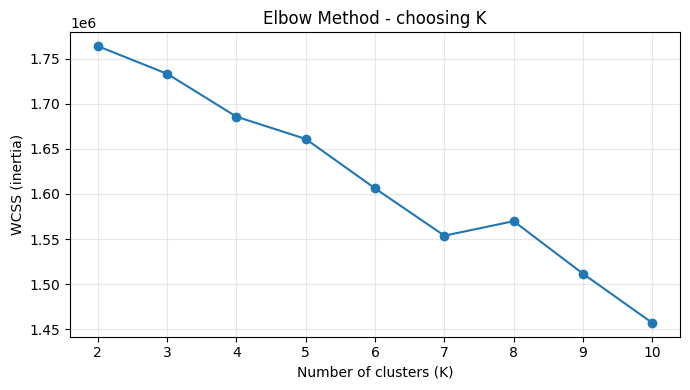

K= 2  WCSS=1,763,948
K= 3  WCSS=1,733,279
K= 4  WCSS=1,685,721
K= 5  WCSS=1,660,989
K= 6  WCSS=1,606,180
K= 7  WCSS=1,553,710
K= 8  WCSS=1,569,823
K= 9  WCSS=1,511,533
K=10  WCSS=1,456,983


In [32]:
from sklearn.cluster import MiniBatchKMeans

K_RANGE = range(2, 11)
inertias = []
for k in K_RANGE:
    km = MiniBatchKMeans(n_clusters=k, random_state=RNG, n_init=10, batch_size=4096)
    km.fit(X_sub_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(list(K_RANGE), inertias, marker="o")
plt.xlabel("Number of clusters (K)")
plt.ylabel("WCSS (inertia)")
plt.title("Elbow Method - choosing K")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

for k, val in zip(K_RANGE, inertias):
    print(f"K={k:2d}  WCSS={val:,.0f}")

### 7c.5 Silhouette Analysis

The Silhouette Score is calculated for several candidate values of K to evaluate cluster cohesion and separation. Higher values indicate better-defined clusters and complement the Elbow Method when selecting the final number of clusters.

In [33]:
from sklearn.metrics import silhouette_score

sil_idx = np.random.default_rng(RNG).choice(
    len(X_sub_scaled), size=min(5000, len(X_sub_scaled)), replace=False)

CANDIDATE_KS = [3, 4, 5, 6]
sil_scores = {}
for k in CANDIDATE_KS:
    km = MiniBatchKMeans(n_clusters=k, random_state=RNG, n_init=10, batch_size=4096)
    labels = km.fit_predict(X_sub_scaled)
    sil_scores[k] = silhouette_score(X_sub_scaled[sil_idx], labels[sil_idx])

for k, s in sil_scores.items():
    print(f"K={k}  silhouette={s:.3f}")

K=3  silhouette=0.029
K=4  silhouette=0.054
K=5  silhouette=0.059
K=6  silhouette=0.052


### 7c.6 Final Clustering Model

The Elbow Method suggested an appropriate solution around four to five clusters. Although K = 5 achieved a slightly higher Silhouette Score, the improvement was marginal. Therefore, K = 4 was selected as a more parsimonious and interpretable clustering solution for the final model.

In [34]:
FINAL_K = 4

X_full = build_feature_matrix(df_u, num_feats, bin_feats, cat_feats)
X_full = X_full.reindex(columns=X_sub.columns, fill_value=0)  # align dummy columns
X_full_scaled = scaler.transform(X_full)

kmeans_final = MiniBatchKMeans(n_clusters=FINAL_K, random_state=RNG,
                               n_init=10, batch_size=8192)
df_u["cluster"] = kmeans_final.fit_predict(X_full_scaled)

print("Cluster sizes:")
print(df_u["cluster"].value_counts().sort_index())

Cluster sizes:
cluster
0    850240
1     45351
2    114717
3     21435
Name: count, dtype: int64


### 7c.7 Cluster Visualization using PCA

Since the clustering is performed in a high-dimensional feature space, Principal Component Analysis (PCA) is used to project the data into two dimensions for visualization. This projection allows the identified clusters to be displayed while preserving as much variance as possible.

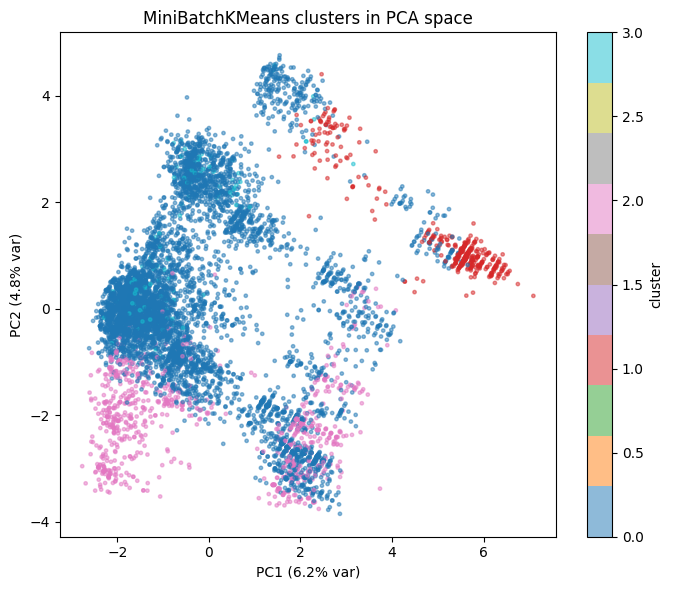

Explained variance (PC1, PC2): [0.062 0.048]


In [35]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=RNG).fit(X_full_scaled)

plot_idx = np.random.default_rng(RNG).choice(
    len(X_full_scaled), size=min(8000, len(X_full_scaled)), replace=False)
coords = pca.transform(X_full_scaled[plot_idx])
clusters_plot = df_u["cluster"].values[plot_idx]

plt.figure(figsize=(7, 6))
sc = plt.scatter(coords[:, 0], coords[:, 1], c=clusters_plot,
                 cmap="tab10", s=6, alpha=0.5)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
plt.title("MiniBatchKMeans clusters in PCA space")
plt.colorbar(sc, label="cluster")
plt.tight_layout()
plt.show()

print("Explained variance (PC1, PC2):", pca.explained_variance_ratio_[:2].round(3))

### 7c.8 Cluster Profiling

After assigning each observation to a cluster, descriptive statistics are calculated to summarize the main characteristics of each group. These profiles facilitate the interpretation of the discovered clusters by comparing demographic, educational, and organizational attributes.

In [37]:
def wmean(values, weights):
    w = np.asarray(weights, dtype=float)
    v = np.asarray(values, dtype=float)
    return np.average(v, weights=w) if w.sum() > 0 else np.nan

rows = []
for c, g in df_u.groupby("cluster"):
    row = {"cluster": c, "n": len(g), "share_of_data": len(g) / len(df_u),
           "female_share_w": wmean(g["female"], g["gender_weight"]),
           "exec_rate_w": wmean(g["has_any_executive_role"], g["directorid_weight"])}
    for col in num_feats:
        row[f"mean_{col}"] = g[col].mean()
    for col in bin_feats:
        row[f"rate_{col}"] = g[col].mean()
    row["top_sector"] = g["sector_company"].mode().iloc[0]
    row["top_orgtype"] = g["orgtype_company"].mode().iloc[0]
    row["top_hocountry"] = g["hocountryname"].mode().iloc[0]
    rows.append(row)

cluster_profile = pd.DataFrame(rows).set_index("cluster").round(3)
# Show the most decision-relevant columns first
lead = ["n", "share_of_data", "female_share_w", "exec_rate_w",
        "mean_age", "mean_num_qualifications", "top_sector", "top_orgtype", "top_hocountry"]
lead = [c for c in lead if c in cluster_profile.columns]
display(cluster_profile[lead])
cluster_profile  # full table (all rate_* columns) below

,n,share_of_data,female_share_w,exec_rate_w,mean_age,mean_num_qualifications,top_sector,top_orgtype,top_hocountry
cluster,,,,,,,,,
0,850240,0.824,0.504,0.416,59.149,1.957,Missing,Private,Other
1,45351,0.044,0.449,0.000,59.678,2.067,Missing,Missing,United Kingdom - England
2,114717,0.111,0.483,0.128,57.699,2.051,Missing,Missing,United Kingdom - England
3,21435,0.021,0.544,0.459,58.912,1.957,Health,Private,Sweden


,n,share_of_data,female_share_w,exec_rate_w,mean_age,mean_num_qualifications,rate_brdposition_binary,rate_leadershipteam_binary,rate_ned_binary,rate_is_chairman,...,rate_is_owner_investor,rate_is_employee_representative,rate_is_manager_operational,rate_has_mba,rate_has_phd,rate_has_master,rate_has_bachelor,top_sector,top_orgtype,top_hocountry
cluster,,,,,,,,,,,,,,,,,,,,,
0,850240,0.824,0.504,0.416,59.149,1.957,0.359,0.091,0.268,0.067,...,0.016,0.022,0.071,0.161,0.117,0.312,0.297,Missing,Private,Other
1,45351,0.044,0.449,0.000,59.678,2.067,1.000,0.000,1.000,0.002,...,0.000,0.000,0.000,0.171,0.081,0.305,0.420,Missing,Missing,United Kingdom - England
2,114717,0.111,0.483,0.128,57.699,2.051,0.123,0.055,0.030,0.021,...,0.006,0.001,0.071,0.145,0.120,0.347,0.312,Missing,Missing,United Kingdom - England
3,21435,0.021,0.544,0.459,58.912,1.957,0.374,0.153,0.287,0.066,...,0.015,0.029,0.057,0.167,0.162,0.330,0.283,Health,Private,Sweden


### 7c.9 Export Cluster Assignments

The final cluster assignments are exported to a separate file to ensure reproducibility and allow their use in subsequent analyses if required.

In [61]:
cluster_handoff = df_u[["directorid", "cluster"]].copy()
cluster_handoff.to_csv("cluster_ids.csv", index=False)
print("Saved cluster_ids.csv with", len(cluster_handoff), "rows,",
      cluster_handoff["cluster"].nunique(), "clusters.")

Saved cluster_ids.csv with 1031743 rows, 4 clusters.


### 8. Synthesis of findings 

The project uses three methodological lenses: causal inference, supervised learning, and unsupervised learning. Each block reveals something the others miss.

The causal inference block estimates the adjusted disparity in access to top roles. The baseline gap is about −2.5 percentage points, but after adjustment it widens to about −4.7 percentage points. The adjusted gap is larger than the naive gap within the causal model used. The observed confounders do not explain away the gender gap. Instead, the estimated disadvantage for women becomes larger after adjustment. However, this estimate may be sensitive to imbalance and repeated observations, because the balancing variables created in the cleaning stage were not used in the methodology. We should have tested how much the results changed after applying these weights and compared the weighted estimates with the unweighted baseline.

The supervised learning block shows whether gender still matters in a predictive setting after many other variables are included. Logistic regression shows a negative coefficient for female, with an odds ratio of about 0.83. Women have lower odds of holding top positions even after the included characteristics are taken into account. Lasso keeps female non-zero, meaning that the gender association is not fully explained by age, education, sector, nationality, organization type, or board-role context. The random forest adds that the strongest predictive variables are board and role-context indicators, such as ned_binary, is_partner, is_board_member_sd, brdposition_binary, and is_advisor. It shows that the model relies mostly on role indicators, not on demographic or other variables. This suggests that a person who already has a high position is more likely to get the highest role.

The unsupervised learning block shows heterogeneity across different types of role records without using executive status as the prediction target. For example, Cluster 0 is the largest and most general group, containing about 82.4% of the data. It has a roughly balanced female share of 0.504 and a relatively high executive rate of 0.416. Its dominant organization type is Private, while sector is mostly Missing and the top head-office country is Other. Cluster 1 is a small board-related group, containing about 4.4% of the data. It has no executive-role observations, but both rate_brdposition_binary and rate_ned_binary are 1.000. This suggests that these records describe non-executive board positions. Cluster 2 contains about 11.1% of the data and has a much lower executive rate of 0.128. It also has more missing sector and organization information, with United Kingdom - England as the top head-office country. Cluster 3 is the smallest group, containing about 2.1% of the data, but it has the highest executive rate of 0.459 and the highest female share of 0.544. Its top sector is Health and its top head-office country is Sweden. This is the cluster where women are more represented and executive access is relatively high. However, because the silhouette score is low and cluster separation is weak, these clusters should be interpreted as exploratory patterns rather than strong natural groups. Still, the clustering block gives a different perspective from the other two blocks because it shows how the data are structured into broader role-record profiles, rather than estimating a gender gap in predicting executive status. 

At the same time, the blocks are connected because they point to the same pattern and try to answer the research question from different angles. The strongest interpretation comes from combining the three lenses. From the causal part, we see that the observed variables used in the model do not fully explain the gender gap. There may still be unobserved variables that explain part of the remaining difference.

A similar idea appears in the supervised learning block. Women are less likely to hold higher positions, and this association is not fully explained by age, education, sector, nationality, organization type, or board-role context. The supervised learning results also show that people who already have high positions are more likely to be classified as having even higher roles. This is similar to a “rich get richer” pattern, where existing seniority gives more access to top roles.

One interesting result is that the cluster with the highest female share is connected to Health and Sweden. It does not confirm the previous finding directly, but it suggests that there may be cultural, sectoral, and country-specific contexts that are not fully captured by the other models. So, the gender gap may not be only about individual characteristics in the dataset, but also about broader institutional, cultural, and contextual factors.

### Limitations

The main limitation is that the data are observational. The analysis cannot fully prove that gender itself causes lower executive access. Some important factors, for example, family constraints or company policies etc. are not observed in the data.

The second limitation is that, in the causal part, gender was not balanced, and in both blocks, variables such as gender_weight and directorid_weight were not used. They were used in the unsupervised part, but again not the personal director id weighting, even though the same person could have more than one role.

The unsupervised learning block has additional limitations. K-means and plotting with PCA are not ideal for data with many categorical and one-hot encoded variables. K-means relies on distance between observations, while PCA is designed to summarize continuous numeric variation. For example, we created a variable for professional years (years_worked) of experience, but did not include it in the PCA. In the current analysis, the silhouette score is low, and the first two principal components explain only about 11% of the variance. However, we still got some interesting interpetations.

The results mainly represent the most frequent countries in the dataset, and the patterns may differ across countries. Since the data cover only a subset of European countries and are concentrated mostly in Germany and France, the analysis may miss patterns that are specific to smaller countries in the sample.

Finally, the unsupervised and supervised learning blocks were not fully integrated. The clustering results were interpreted separately, but the cluster labels were not used as additional features in the supervised learning models. The project does not test whether the clusters discovered by K-means improve the prediction.

### Conclusion

This project asked which individual characteristics influence the probability of holding a top position in a company, and whether gender remains associated with this probability after accounting for  factors.

Overall, the results show that gender is an important predictor, but the factors that were chosen do not always fully explain access to top positions. Executive access is strongly related to role and board context, such as board position, non-executive director status, partner status, advisory roles, and board membership. Age also matters, while education, nationality, sector, organization type, and country context help describe differences across role records. However, these observed characteristics do not fully explain the gender gap.

Across the causal and supervised learning blocks, gender remains negatively associated with access to top roles. In the causal block, the adjusted gender gap is larger than the naive gap, suggesting that the observed confounders do not explain away the disadvantage for women. In the supervised learning block, female remains a negative predictor in logistic regression. The lasso result is consistent with this pattern.

The unsupervised learning block adds that executive access is not distributed evenly across all role-record profiles. Some clusters have higher executive rates and different female shares. This may suggest that institutional, sectoral, and country-specific contexts also matter.

The main conclusion is that gender still appears to be an important factor and remains associated with access to top positions even after several observed individual and organizational characteristics are included. At the same time, the data are observational, do not include all possible relevant variables, and cover only European data rather than global data. We also did not directly analyse contextual and cultural factors. Therefore, the results should be interpreted as evidence of an existing gender disparity, but with caution because the analysis does not capture all possible individual, organizational, and contextual explanations for this gap.